# Fake Product Review Detection: Understanding the Data & Preparing the Pipeline

## 1. Introduction
In the digital age, fake reviews can significantly influence consumer behavior and brand reputation. This notebook documents the initial phase of our project: **Exploratory Data Analysis (EDA)** and **Text Preprocessing**. 

**Our Narrative:**
We aren't just cleaning text; we are investigating the "fingerprints" of fake reviews. By analyzing distribution, length, and common words, we aim to uncover patterns that distinguish computer-generated (CG) reviews from original (OR) human-written ones.

---


In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tqdm import tqdm

# Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## 2. Environment Setup
We ensure all necessary NLTK resources are available for tokenization, stopword removal, and lemmatization.


In [2]:
def setup_nltk():
    resources = ['punkt', 'stopwords', 'wordnet', 'omw-1.4']
    for r in resources:
        try:
            nltk.data.find(r)
        except LookupError:
            nltk.download(r)

setup_nltk()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mohsen\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mohsen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mohsen\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Mohsen\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 3. Data Loading & Initial Inspection
We load the raw dataset and perform a quick check of its structure. Consistency in column naming is established here.


In [3]:
DATA_PATH = '../data/raw/fake_reviews.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

df.rename(columns={'text_': 'review'}, inplace=True)
if 'review' not in df.columns or 'label' not in df.columns:
    print("Warning: Columns not as expected. Current columns:", df.columns)

print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset Dimensions: 40432 rows, 4 columns


,category,rating,label,review
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


## 4. Exploratory Data Analysis (EDA)
### 4.1. Class Balance
Is our dataset biased? A balanced dataset is crucial for training a fair classifier.


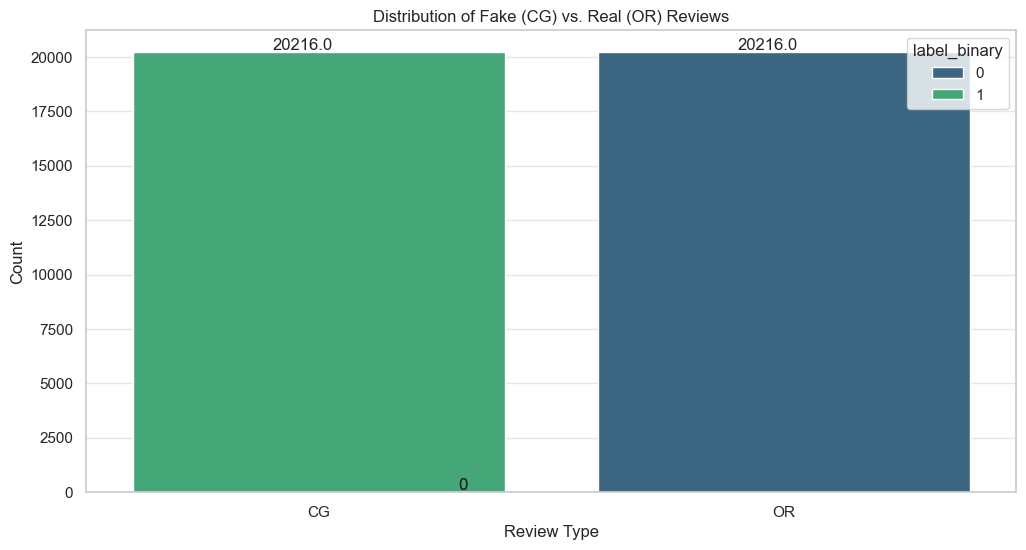

In [4]:
# Mapping labels: CG (Computer Generated) -> 1, OR (Original) -> 0
df['label_binary'] = df['label'].map({'CG': 1, 'OR': 0})

ax = sns.countplot(x='label', data=df, palette='viridis', hue='label_binary')
plt.title("Distribution of Fake (CG) vs. Real (OR) Reviews")
plt.xlabel("Review Type")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 100))
plt.show()


### 4.2. Review Length Analysis
Do fake reviews tend to be shorter or longer? We analyze both character length and word count.


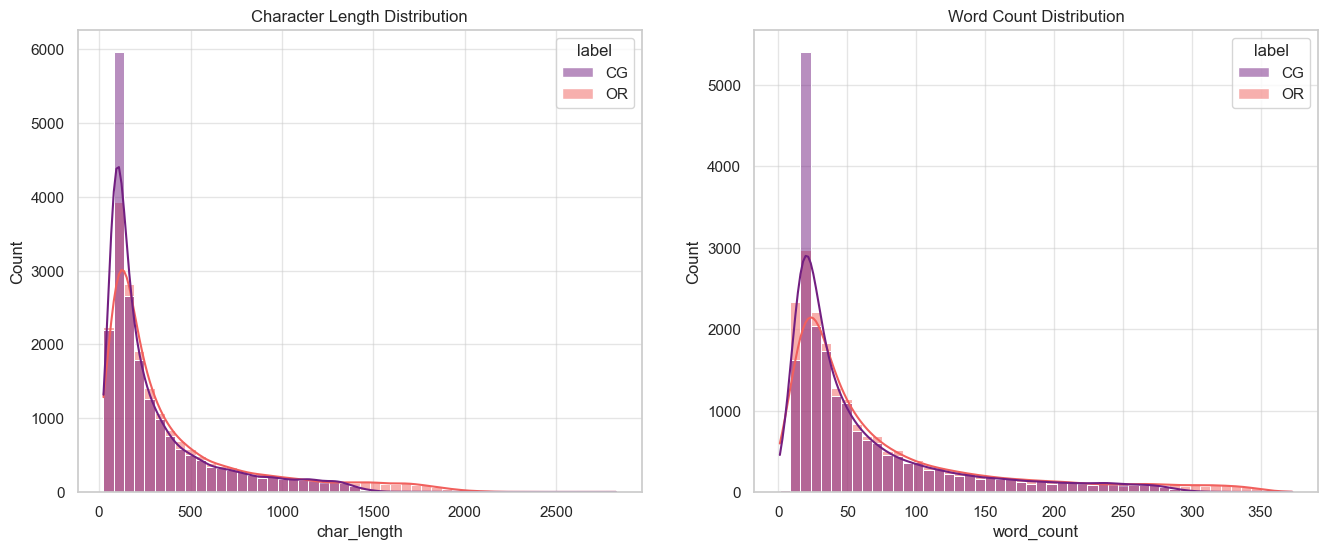

In [5]:
df['char_length'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x='char_length', hue='label', kde=True, bins=50, ax=ax1, palette='magma')
ax1.set_title("Character Length Distribution")

sns.histplot(data=df, x='word_count', hue='label', kde=True, bins=50, ax=ax2, palette='magma')
ax2.set_title("Word Count Distribution")

plt.show()


### 4.3. Visualizing the Vocabulary: Word Clouds
What are the most frequent words in each category?


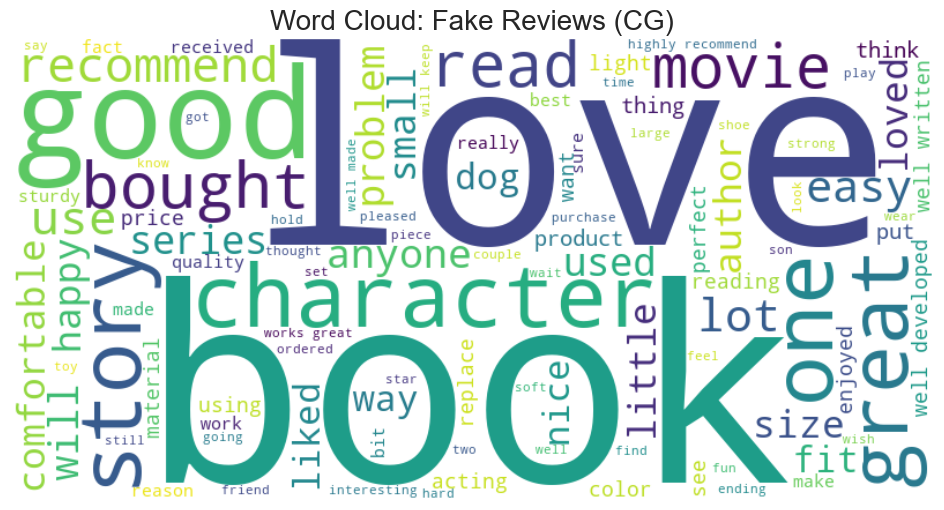

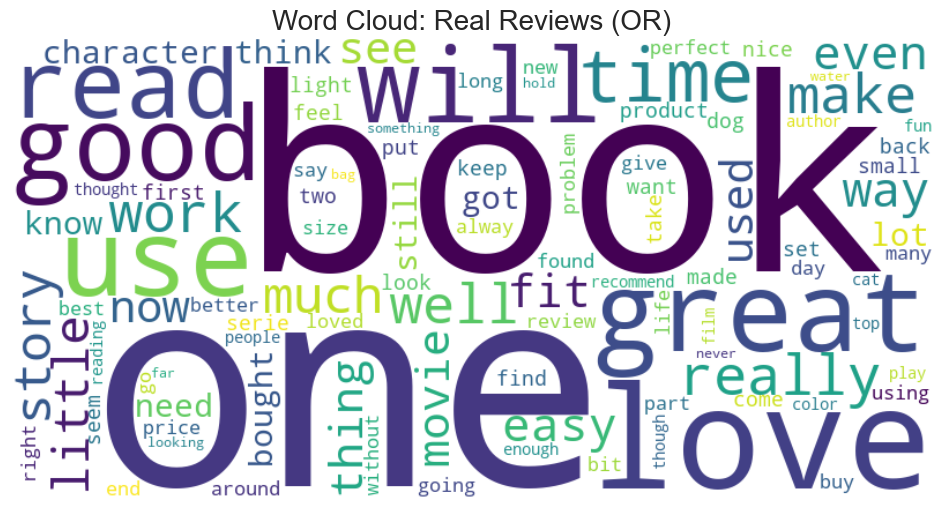

In [6]:
def generate_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

fake_text = " ".join(df[df['label'] == 'CG']['review'].astype(str))
real_text = " ".join(df[df['label'] == 'OR']['review'].astype(str))

generate_wordcloud(fake_text, "Word Cloud: Fake Reviews (CG)")
generate_wordcloud(real_text, "Word Cloud: Real Reviews (OR)")


## 5. Text Preprocessing Pipeline
To make the text suitable for machine learning, we need to:
1.  **Lowerization**: Convert to lowercase for uniformity.
2.  **Noise Removal**: Remove URLs, numbers, and special characters.
3.  **Tokenization**: Split text into individual words.
4.  **Stopword Removal**: Remove common words (e.g., 'the', 'is') that don't carry significant meaning.
5.  **Lemmatization**: Reduce words to their base/dictionary form (e.g., 'running' -> 'run').


In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Basic cleaning
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)  # Remove URLs
    text = re.sub(r'\d+', ' ', text)             # Remove numbers
    text = re.sub(r'[^\w\s]', ' ', text)         # Remove punctuation

    # Tokenization & Advanced cleaning
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return " ".join(tokens)

print("Starting preprocessing...")
tqdm.pandas()
df['cleaned_review'] = df['review'].progress_apply(clean_text)

# Preview results
df[['review', 'cleaned_review']].head()


Starting preprocessing...


100%|██████████| 40432/40432 [00:52<00:00, 767.00it/s] 


,review,cleaned_review
0,"Love this! Well made, sturdy, and very comfor...",love well made sturdy comfortable love pretty
1,"love it, a great upgrade from the original. I...",love great upgrade original mine couple year
2,This pillow saved my back. I love the look and...,pillow saved back love look feel pillow
3,"Missing information on how to use it, but it i...",missing information use great product price
4,Very nice set. Good quality. We have had the s...,nice set good quality set two month


## 6. Saving the Results
The cleaned dataset will serve as the foundation for our feature extraction (TF-IDF/Embeddings) and model training.


In [8]:
OUTPUT_PATH = '../data/preprocessed/cleaned_reviews.csv'
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

df.to_csv(OUTPUT_PATH, index=False)
print(f"Successfully saved {len(df)} preprocessed reviews to: {OUTPUT_PATH}")


Successfully saved 40432 preprocessed reviews to: ../data/preprocessed/cleaned_reviews.csv
